## EDA - Стоимость подержанного автомобиля

In [370]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder


In [371]:
data = pd.read_csv("../cars.csv")

## Исследование исходных данных

In [372]:
data.columns

Index(['manufacturer_name', 'model_name', 'transmission', 'color',
       'odometer_value', 'year_produced', 'engine_fuel', 'engine_has_gas',
       'engine_type', 'engine_capacity', 'body_type', 'has_warranty', 'state',
       'drivetrain', 'price_usd', 'is_exchangeable', 'location_region',
       'number_of_photos', 'up_counter', 'feature_0', 'feature_1', 'feature_2',
       'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7',
       'feature_8', 'feature_9', 'duration_listed'],
      dtype='object')

Описание датасета

'manufacturer_name' - марка
'model_name' - модель
'transmission' - тип коробки
'color' - цвет
'odometer_value' - пробег
'year_produced' - год
'engine_fuel' - тип топлива
'engine_has_gas' - Is the car equipped with propane tank and tubing?
'engine_type'-  тип мотра
'engine_capacity' - обьем
'body_type' - кузов
'has_warranty' -гаран
'state' - состояние
'drivetrain' -привод
'price_usd'- цена(Целевой)
'is_exchangeable'- обмен
'location_region'- место
'number_of_photos' -колво фото
'up_counter'- Number of times the car has been upped, numerical.
'feature_0',
'feature_1',
'feature_2',
'feature_3',
'feature_4',
'feature_5',
'feature_6',
'feature_7',
'feature_8',
'feature_9', 
'duration_listed -Number of days the car is listed in the catalog.

In [373]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38531 entries, 0 to 38530
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   manufacturer_name  38531 non-null  object 
 1   model_name         38531 non-null  object 
 2   transmission       38531 non-null  object 
 3   color              38531 non-null  object 
 4   odometer_value     38531 non-null  int64  
 5   year_produced      38531 non-null  int64  
 6   engine_fuel        38531 non-null  object 
 7   engine_has_gas     38531 non-null  bool   
 8   engine_type        38531 non-null  object 
 9   engine_capacity    38521 non-null  float64
 10  body_type          38531 non-null  object 
 11  has_warranty       38531 non-null  bool   
 12  state              38531 non-null  object 
 13  drivetrain         38531 non-null  object 
 14  price_usd          38531 non-null  float64
 15  is_exchangeable    38531 non-null  bool   
 16  location_region    385

In [374]:
data.head()

,manufacturer_name,model_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_has_gas,engine_type,engine_capacity,...,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,duration_listed
0,Subaru,Outback,automatic,silver,190000,2010,gasoline,False,gasoline,2.5,...,True,True,True,False,True,False,True,True,True,16
1,Subaru,Outback,automatic,blue,290000,2002,gasoline,False,gasoline,3.0,...,True,False,False,True,True,False,False,False,True,83
2,Subaru,Forester,automatic,red,402000,2001,gasoline,False,gasoline,2.5,...,True,False,False,False,False,False,False,True,True,151
3,Subaru,Impreza,mechanical,blue,10000,1999,gasoline,False,gasoline,3.0,...,False,False,False,False,False,False,False,False,False,86
4,Subaru,Legacy,automatic,black,280000,2001,gasoline,False,gasoline,2.5,...,True,False,True,True,False,False,False,False,True,7


array([[<Axes: title={'center': 'odometer_value'}>,
        <Axes: title={'center': 'year_produced'}>,
        <Axes: title={'center': 'engine_capacity'}>],
       [<Axes: title={'center': 'price_usd'}>,
        <Axes: title={'center': 'number_of_photos'}>,
        <Axes: title={'center': 'up_counter'}>],
       [<Axes: title={'center': 'duration_listed'}>, <Axes: >, <Axes: >]],
      dtype=object)

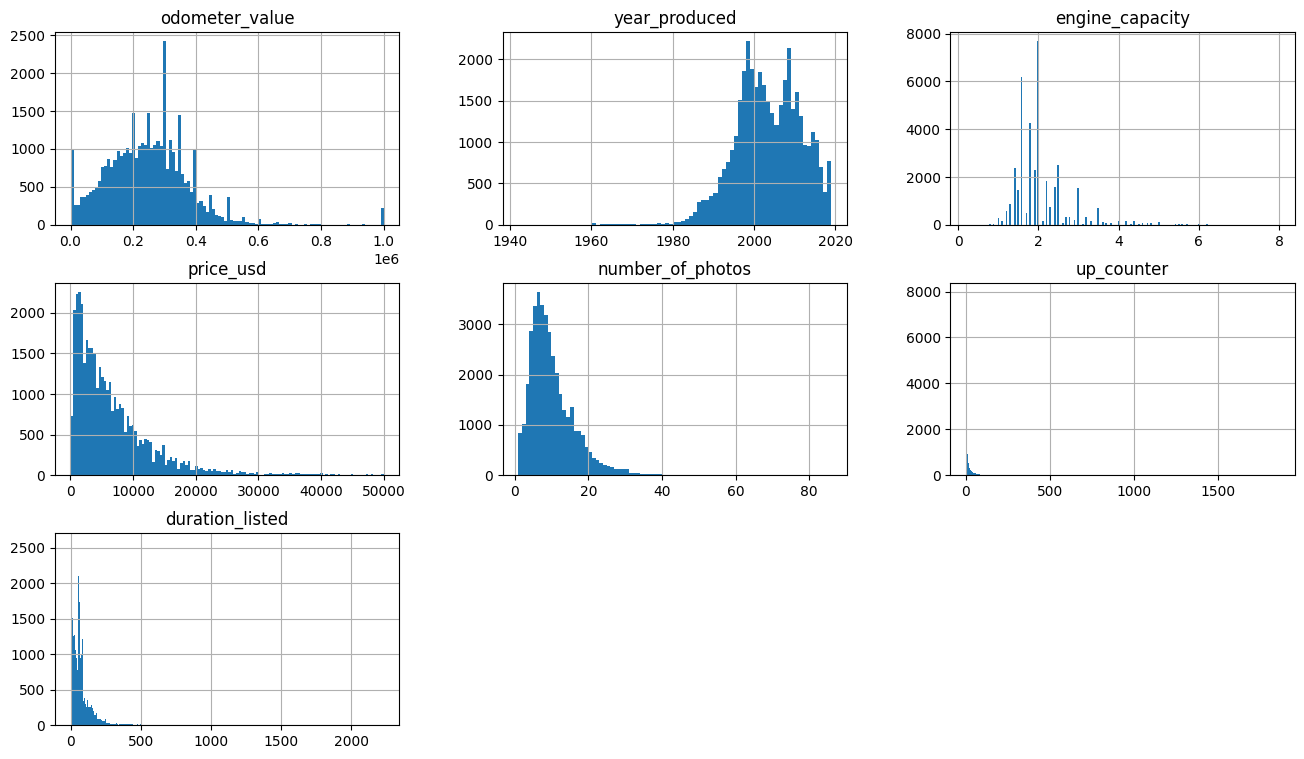

In [375]:
## Plotting numerical features histogram's
data.hist(bins='auto', figsize=(16,9))

In [376]:
bool_distrib_data = data.select_dtypes(bool)
bool_distrib_data = pd.DataFrame({True: bool_distrib_data.sum(), False: data.shape[0] - bool_distrib_data.sum()})
bool_distrib_data.transpose()

,engine_has_gas,has_warranty,is_exchangeable,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9
True,1347,449,13586,8806,23396,8624,10627,9304,13720,6588,10162,16003,22325
False,37184,38082,24945,29725,15135,29907,27904,29227,24811,31943,28369,22528,16206


### Очистка данных

In [377]:
data.duplicated().sum()

np.int64(40)

In [378]:
data.drop_duplicates(ignore_index=True)

,manufacturer_name,model_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_has_gas,engine_type,engine_capacity,...,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,duration_listed
0,Subaru,Outback,automatic,silver,190000,2010,gasoline,False,gasoline,2.5,...,True,True,True,False,True,False,True,True,True,16
1,Subaru,Outback,automatic,blue,290000,2002,gasoline,False,gasoline,3.0,...,True,False,False,True,True,False,False,False,True,83
2,Subaru,Forester,automatic,red,402000,2001,gasoline,False,gasoline,2.5,...,True,False,False,False,False,False,False,True,True,151
3,Subaru,Impreza,mechanical,blue,10000,1999,gasoline,False,gasoline,3.0,...,False,False,False,False,False,False,False,False,False,86
4,Subaru,Legacy,automatic,black,280000,2001,gasoline,False,gasoline,2.5,...,True,False,True,True,False,False,False,False,True,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38486,Chrysler,300,automatic,silver,290000,2000,gasoline,False,gasoline,3.5,...,True,False,False,True,True,False,False,True,True,301
38487,Chrysler,PT Cruiser,mechanical,blue,321000,2004,diesel,False,diesel,2.2,...,True,False,False,True,True,False,False,True,True,317
38488,Chrysler,300,automatic,blue,777957,2000,gasoline,False,gasoline,3.5,...,True,False,False,True,True,False,False,True,True,369
38489,Chrysler,PT Cruiser,mechanical,black,20000,2001,gasoline,False,gasoline,2.0,...,True,False,False,False,False,False,False,False,True,490


In [379]:
(data.isna().sum()/data.shape[0]*100).sort_values(ascending=False)

engine_capacity      0.025953
manufacturer_name    0.000000
transmission         0.000000
color                0.000000
odometer_value       0.000000
model_name           0.000000
year_produced        0.000000
engine_fuel          0.000000
engine_has_gas       0.000000
engine_type          0.000000
body_type            0.000000
has_warranty         0.000000
state                0.000000
drivetrain           0.000000
price_usd            0.000000
is_exchangeable      0.000000
location_region      0.000000
number_of_photos     0.000000
up_counter           0.000000
feature_0            0.000000
feature_1            0.000000
feature_2            0.000000
feature_3            0.000000
feature_4            0.000000
feature_5            0.000000
feature_6            0.000000
feature_7            0.000000
feature_8            0.000000
feature_9            0.000000
duration_listed      0.000000
dtype: float64

Только в одном признаке это обьем мотора:
- модем заполнить модой тк это всего 10 пропусков

In [380]:
data.fillna({"engine_capacity": data['engine_capacity'].mode()}, inplace=True)

In [381]:
(data.isna().sum()/data.shape[0]*100).sort_values(ascending=False)

engine_capacity      0.025953
manufacturer_name    0.000000
transmission         0.000000
color                0.000000
odometer_value       0.000000
model_name           0.000000
year_produced        0.000000
engine_fuel          0.000000
engine_has_gas       0.000000
engine_type          0.000000
body_type            0.000000
has_warranty         0.000000
state                0.000000
drivetrain           0.000000
price_usd            0.000000
is_exchangeable      0.000000
location_region      0.000000
number_of_photos     0.000000
up_counter           0.000000
feature_0            0.000000
feature_1            0.000000
feature_2            0.000000
feature_3            0.000000
feature_4            0.000000
feature_5            0.000000
feature_6            0.000000
feature_7            0.000000
feature_8            0.000000
feature_9            0.000000
duration_listed      0.000000
dtype: float64

Пропуски убранны

### Коррекция типов данных

- 0   manufacturer_name  38531 non-null  object 
- 1   model_name         38531 non-null  object 
- 2   transmission       38531 non-null  object 
- 3   color              38531 non-null  object 
- 4   odometer_value     38531 non-null  int64  
- 5   year_produced      38531 non-null  int64  
- 6   engine_fuel        38531 non-null  object 
- 7   engine_has_gas     38531 non-null  bool   
- 8   engine_type        38531 non-null  object 
- 9   engine_capacity    38521 non-null  float64
- 10  body_type          38531 non-null  object 
- 11  has_warranty       38531 non-null  bool   
- 12  state              38531 non-null  object 
- 13  drivetrain         38531 non-null  object 
- 14  price_usd          38531 non-null  float64
- 15  is_exchangeable    38531 non-null  bool   
- 16  location_region    38531 non-null  object 
- 17  number_of_photos   38531 non-null  int64  
- 18  up_counter         38531 non-null  int64  
- 19  feature_0          38531 non-null  bool   
- 20  feature_1          38531 non-null  bool   
- 21  feature_2          38531 non-null  bool   
- 22  feature_3          38531 non-null  bool   
- 23  feature_4          38531 non-null  bool   
- 24  feature_5          38531 non-null  bool   
- 25  feature_6          38531 non-null  bool   
- 26  feature_7          38531 non-null  bool   
- 27  feature_8          38531 non-null  bool   
- 28  feature_9          38531 non-null  bool   
- 29  duration_listed    38531 non-null  int64 

In [382]:
data["drivetrain"].unique()

array(['all', 'front', 'rear'], dtype=object)

- manufacturer_name, model_name, color  - нельзя заменить на one hot,скорее всего от них избавимсмся если нет , корреляции на цену
- engine_type - поскольоку он очень схож с 'engine_fuel' но описывает меньше условийЮ его просто удалисм
- state можем заменить на ранговые
- transmission,  - можно замеить на бинарный признак
- drivetrain - можно замеить на ранговые 
-  location_region, body_type, engine_fuel - можно one-hot

In [383]:
data = data.drop(columns=['engine_type'])

In [384]:
data["transmission"].unique()

array(['automatic', 'mechanical'], dtype=object)

In [385]:
ordinal_encode_f1 = OrdinalEncoder(categories=[['emergency', 'owned', 'new']])
ordinal_encode_f2 = OrdinalEncoder(categories=[['front', 'rear', 'all']])
ordinal_encode_f3 = OrdinalEncoder(categories=[['mechanical','automatic']])


data["transmission"] = ordinal_encode_f3.fit_transform(data[["transmission"]])
data["state"] = ordinal_encode_f1.fit_transform(data[["state"]])
data["drivetrain"] = ordinal_encode_f2.fit_transform(data[["drivetrain"]])

In [386]:
dummies = pd.get_dummies(data[['location_region', 'body_type', 'engine_fuel']], 
                         prefix=['loc', 'body', 'fuel'],  # опционально, для читаемости
                         drop_first=False)  # можно drop_first=True для избежания мультикол
# Удаляем исходные категориальные столбцы
data = data.drop(columns=['location_region', 'body_type', 'engine_fuel'])

# Объединяем дамми-переменные с оставшимися данными
data = pd.concat([data, dummies], axis=1)

In [388]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38531 entries, 0 to 38530
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   manufacturer_name     38531 non-null  object 
 1   model_name            38531 non-null  object 
 2   transmission          38531 non-null  float64
 3   color                 38531 non-null  object 
 4   odometer_value        38531 non-null  int64  
 5   year_produced         38531 non-null  int64  
 6   engine_has_gas        38531 non-null  bool   
 7   engine_capacity       38521 non-null  float64
 8   has_warranty          38531 non-null  bool   
 9   state                 38531 non-null  float64
 10  drivetrain            38531 non-null  float64
 11  price_usd             38531 non-null  float64
 12  is_exchangeable       38531 non-null  bool   
 13  number_of_photos      38531 non-null  int64  
 14  up_counter            38531 non-null  int64  
 15  feature_0          